In [1]:
import pandas as pd
import numpy as np
import os
import mo_gymnasium as mo_gym
import gymnasium as gym
from env.user_sim import UserSimEnv
import env.simulate as sim_utils
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd
import utils
import process_data as dp
from morld.pi_morld import PIMORLD
from pymoo.indicators.hv import HV
from pymoo.operators.survival.rank_and_crowding.metrics import get_crowding_function
from moocore import hypervolume, hv_contributions
import mdp_utils
import pymc as pm
import arviz as az
import pickle

%load_ext autoreload
%autoreload 2

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
c:\Users\shirl\Documents\Studie\2025-2026\Thesis\personalized-coping-challenges\.venv\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
Failed to read module file 'C:\Python311\Lib\shlex.py' for module 'shlex': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\shirl\Documents\Studie\2025-2026\Thesis\personalized-coping-challenges\.venv\Lib\site-pac

In [6]:
cluster_col = 'cluster_all'
state_features = ['tiredness', 'time_avail', 'pu_state']
feature_names = ['Tiredness', 'Time available', 'Perceived usefulness']
cluster_vars = ['obs_diff', 'obs_time', 'obs_liked', 'obs_pu']
cluster_cols = [col + '_cluster' for col in cluster_vars]

reward_cols = ["obs_time", "obs_liked", "obs_pu", "r_expert", "r_diversity"]
obj_names = ["Time Required", "Fun", "Perceived Usefulness", "Expert Usefulness", "Novelty"]

NUM_FEATURES = len(state_features)
NUM_VALS_PER_FEATURE = [2,3,2]
NUM_USER_STATES = np.prod(NUM_VALS_PER_FEATURE)
NUM_CLUSTERS = 6
MAX_COUNT = 2
NUM_COUNT_STATES = (MAX_COUNT+1)**NUM_CLUSTERS
NUM_STATES = NUM_USER_STATES * NUM_COUNT_STATES 
NUM_ACTIONS = NUM_CLUSTERS
NUM_OBJECTIVES = len(reward_cols)

In [10]:
data_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\data\\functions\\3'
results_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\results\\'

# Load data
action_data = pd.read_csv(os.path.join(data_folder, 'action_data.csv'))
samples = pd.read_csv(os.path.join(data_folder, 'samples.csv'))

actions_clustered, _, cluster_cols = dp.cluster_actions(action_data, cluster_vars, num_clusters=6)

df, initial_distribution = dp.process_samples(samples, actions_clustered, state_features, NUM_VALS_PER_FEATURE, cluster_col, MAX_COUNT, NUM_CLUSTERS)
df = df.merge(actions_clustered[['action_id'] + cluster_cols], on='action_id', how='left')
df['obs_time'] = dp.scale_rewards(df['obs_time'].values, reverse=True) * df['completed']

Time rating percentiles:
33.333333333333336th percentile: 3.0000
66.66666666666667th percentile: 5.0000
100.0th percentile: 7.0000


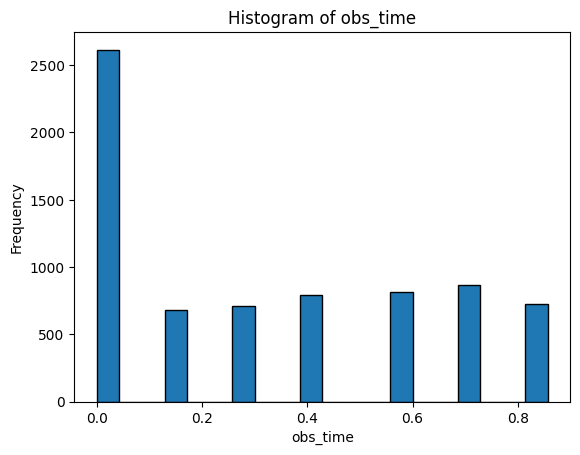

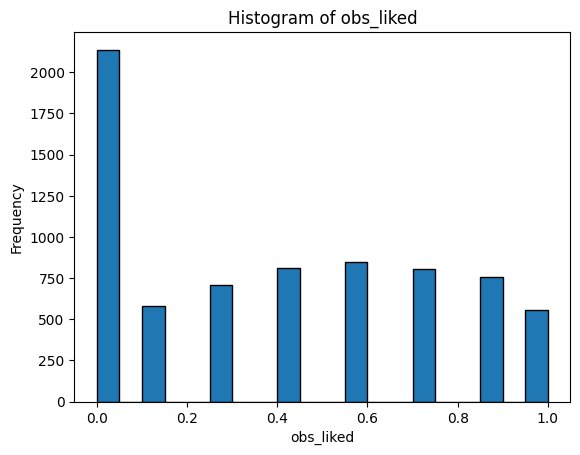

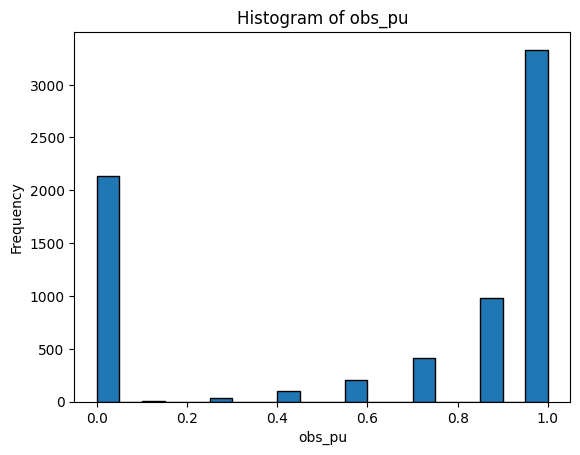

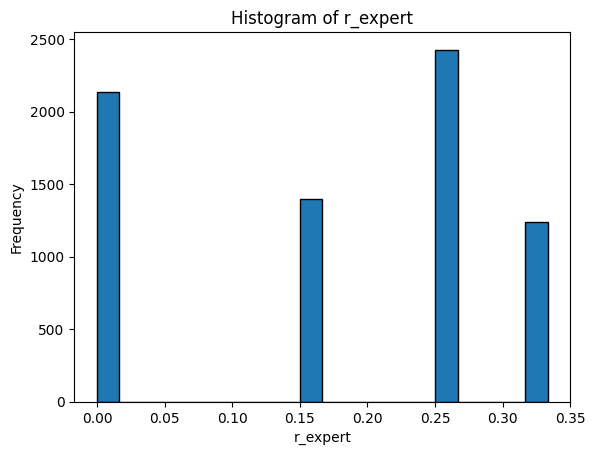

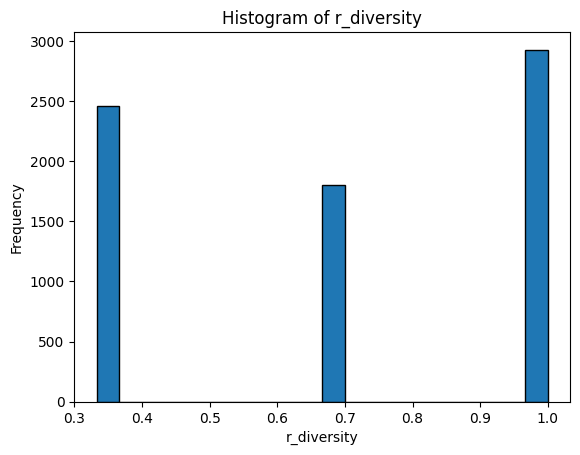

In [9]:
# plot histograms of reward columns
for col in reward_cols:
    plt.figure()
    plt.hist(df[col], bins=20, edgecolor='k')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

Cluster 0:


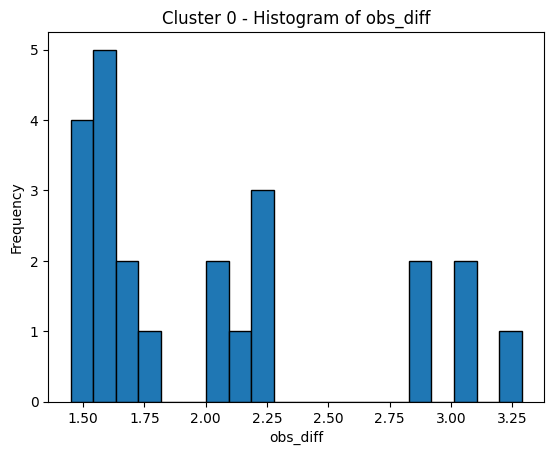

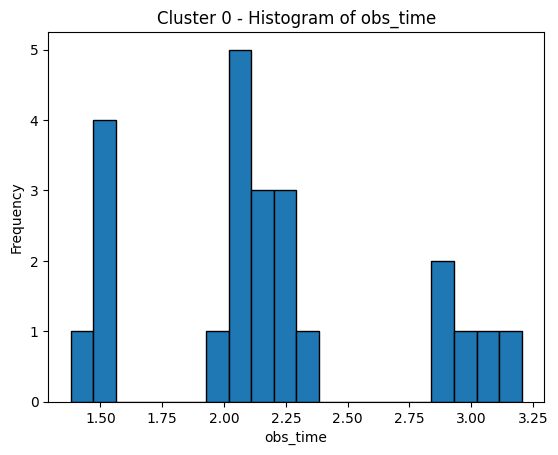

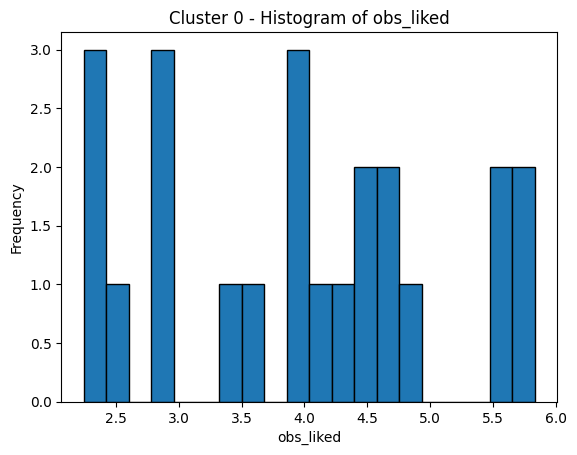

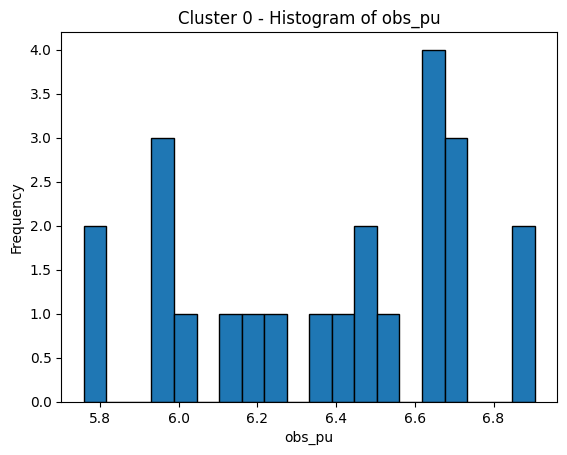

Cluster 1:


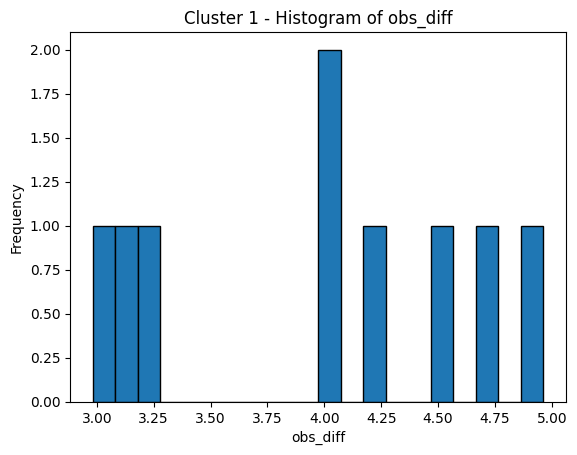

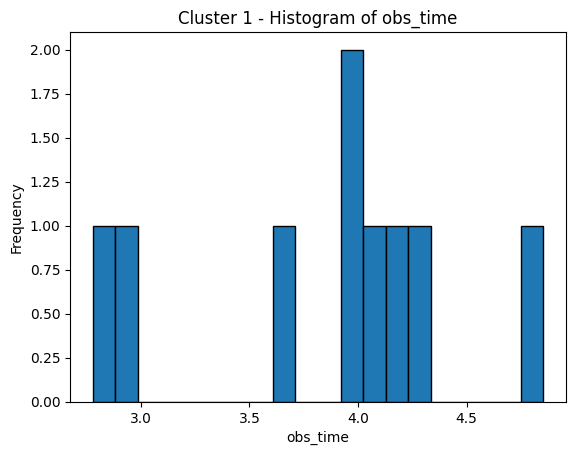

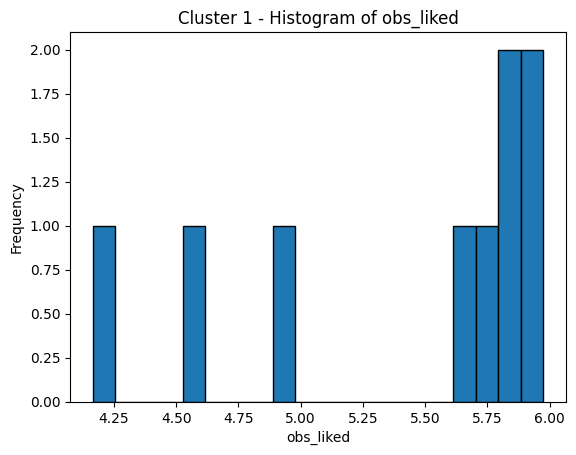

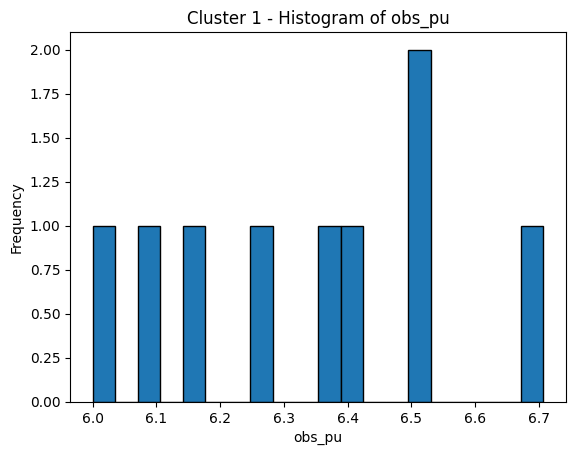

Cluster 2:


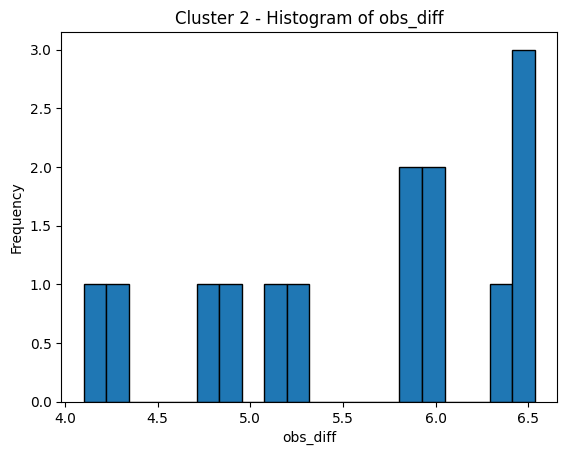

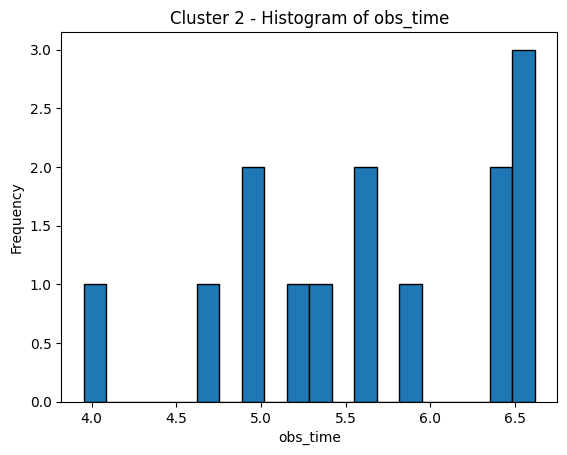

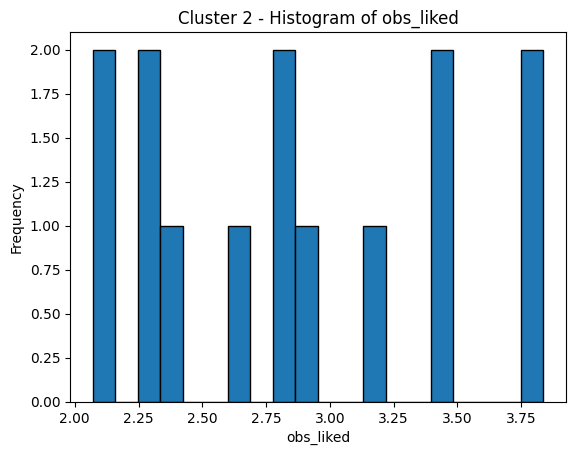

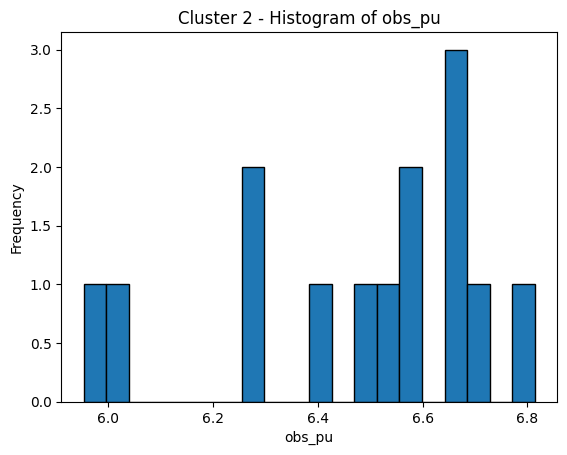

Cluster 3:


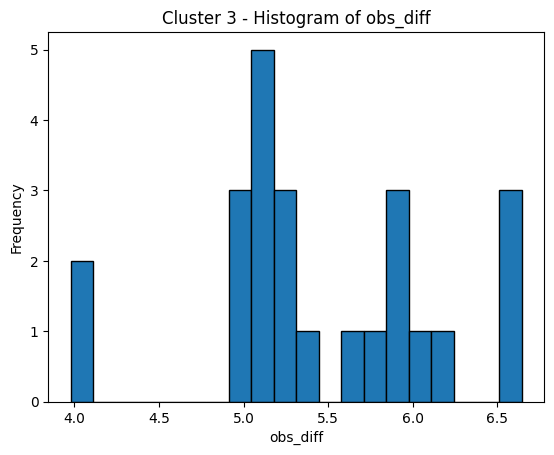

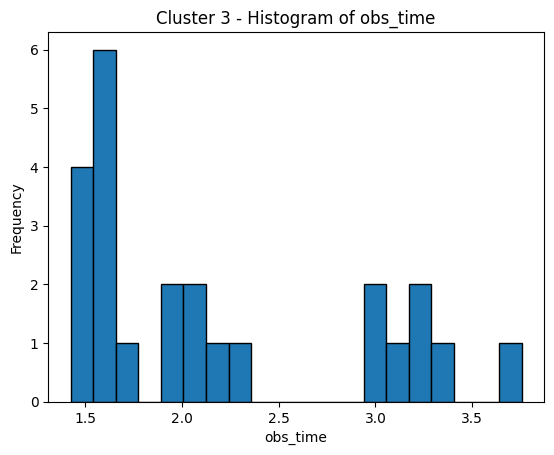

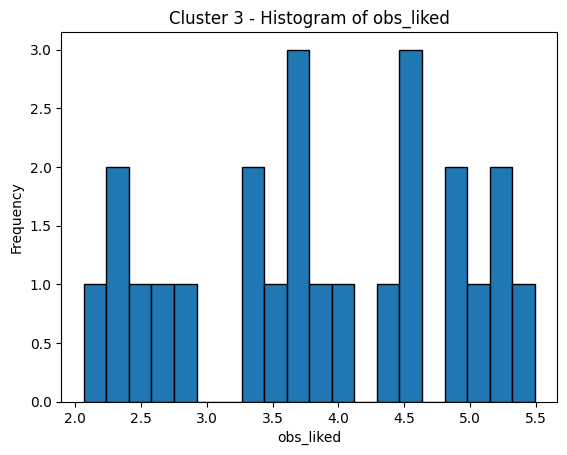

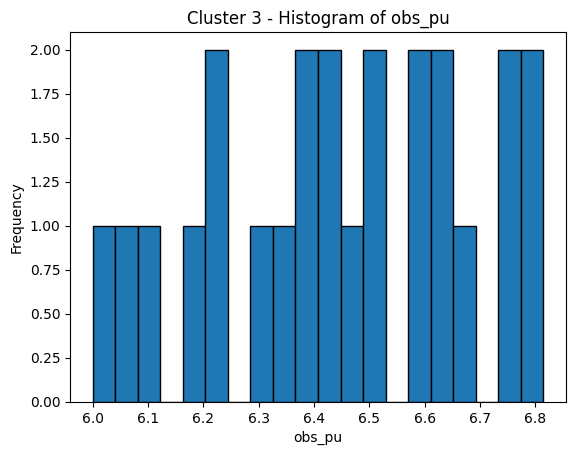

Cluster 4:


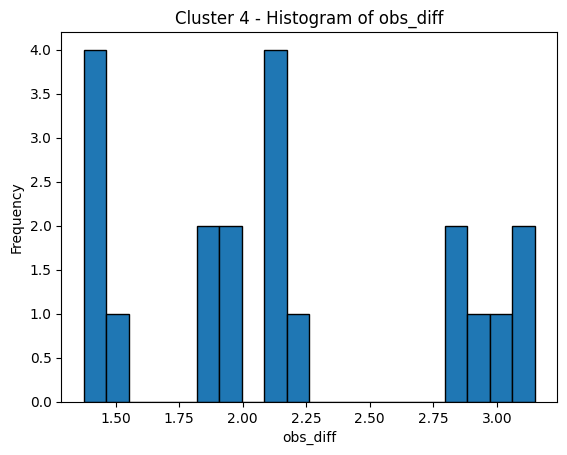

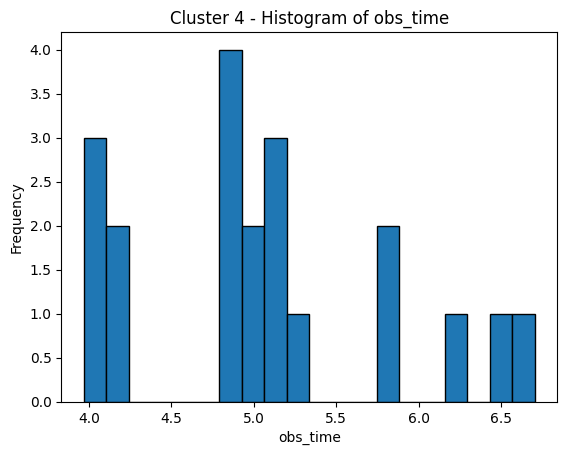

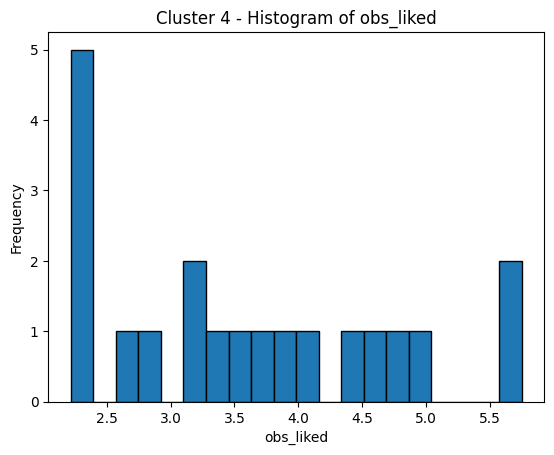

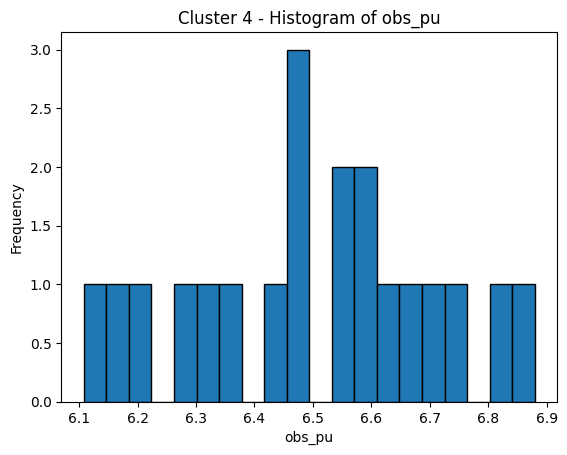

Cluster 5:


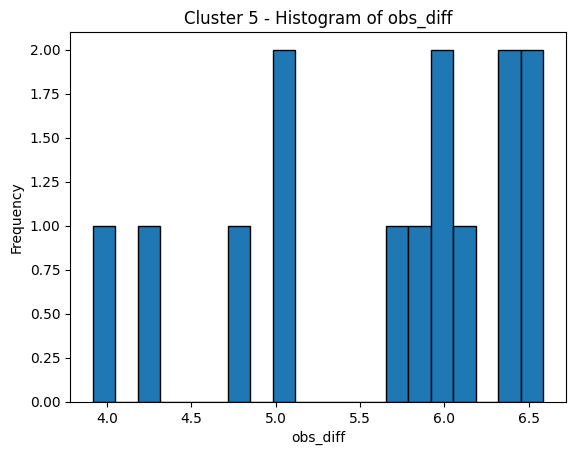

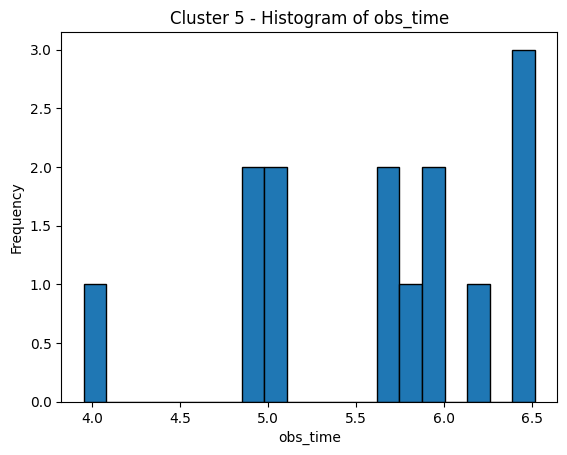

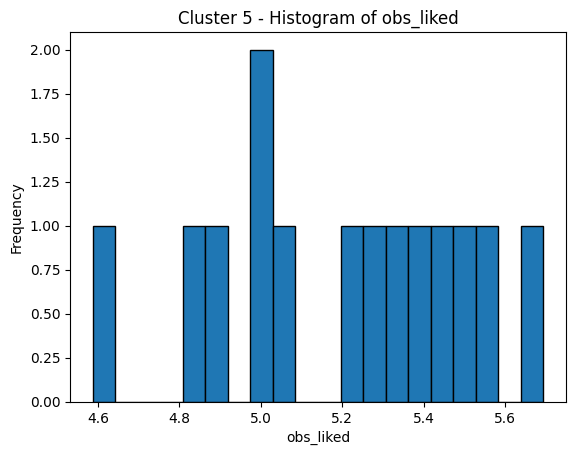

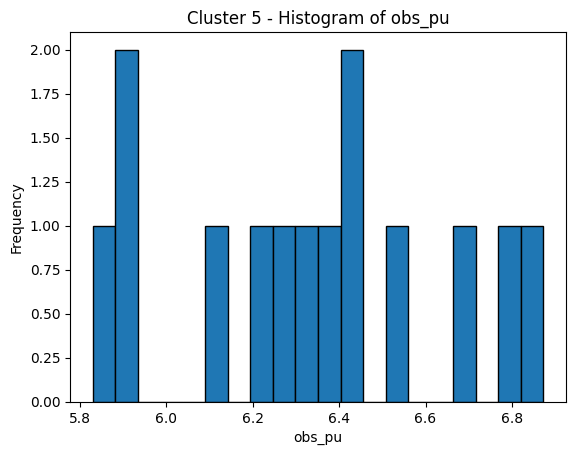

In [14]:
actions_clustered.head()
# for each cluster, plot the distribution of reward columns
for cluster in range(NUM_CLUSTERS):
    cluster_data = actions_clustered[actions_clustered[cluster_col] == cluster]
    print(f'Cluster {cluster}:')
    for col in cluster_vars:
        plt.figure()
        plt.hist(cluster_data[col], bins=20, edgecolor='k')
        plt.title(f'Cluster {cluster} - Histogram of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.show()